
  COMPARING SHOR'S ALGORITHM: N=15 vs N=21

  SHOR'S ALGORITHM: Factoring N = 15
  Parameters:
    - N (number to factor) = 15
    - a (coprime to N) = 7
    - Counting qubits = 8
    - Shots = 2048

  Building quantum circuit...

  Circuit Statistics:
    - Total qubits: 12
    - Counting qubits: 8
    - Work qubits: 4
    - Circuit depth: 3334
    - Total gates: 3376
    - Two-qubit gates: 1052

  Simulating circuit...

  Finding period from measurements...

  Analyzing top measurements:
    10000000 (128): phase = 0.5000, count = 550

  Period r = 2
  a^(r/2) mod N = 7^1 mod 15 = 7
  gcd(7 - 1, 15) = 3
  gcd(7 + 1, 15) = 1

  ✓ SUCCESS! Found factors: 3 × 5 = 15

  SHOR'S ALGORITHM: Factoring N = 21
  Parameters:
    - N (number to factor) = 21
    - a (coprime to N) = 4
    - Counting qubits = 8
    - Shots = 2048

  Building quantum circuit...

  Circuit Statistics:
    - Total qubits: 13
    - Counting qubits: 8
    - Work qubits: 5
    - Circuit depth: 2314
    - Total gates: 2

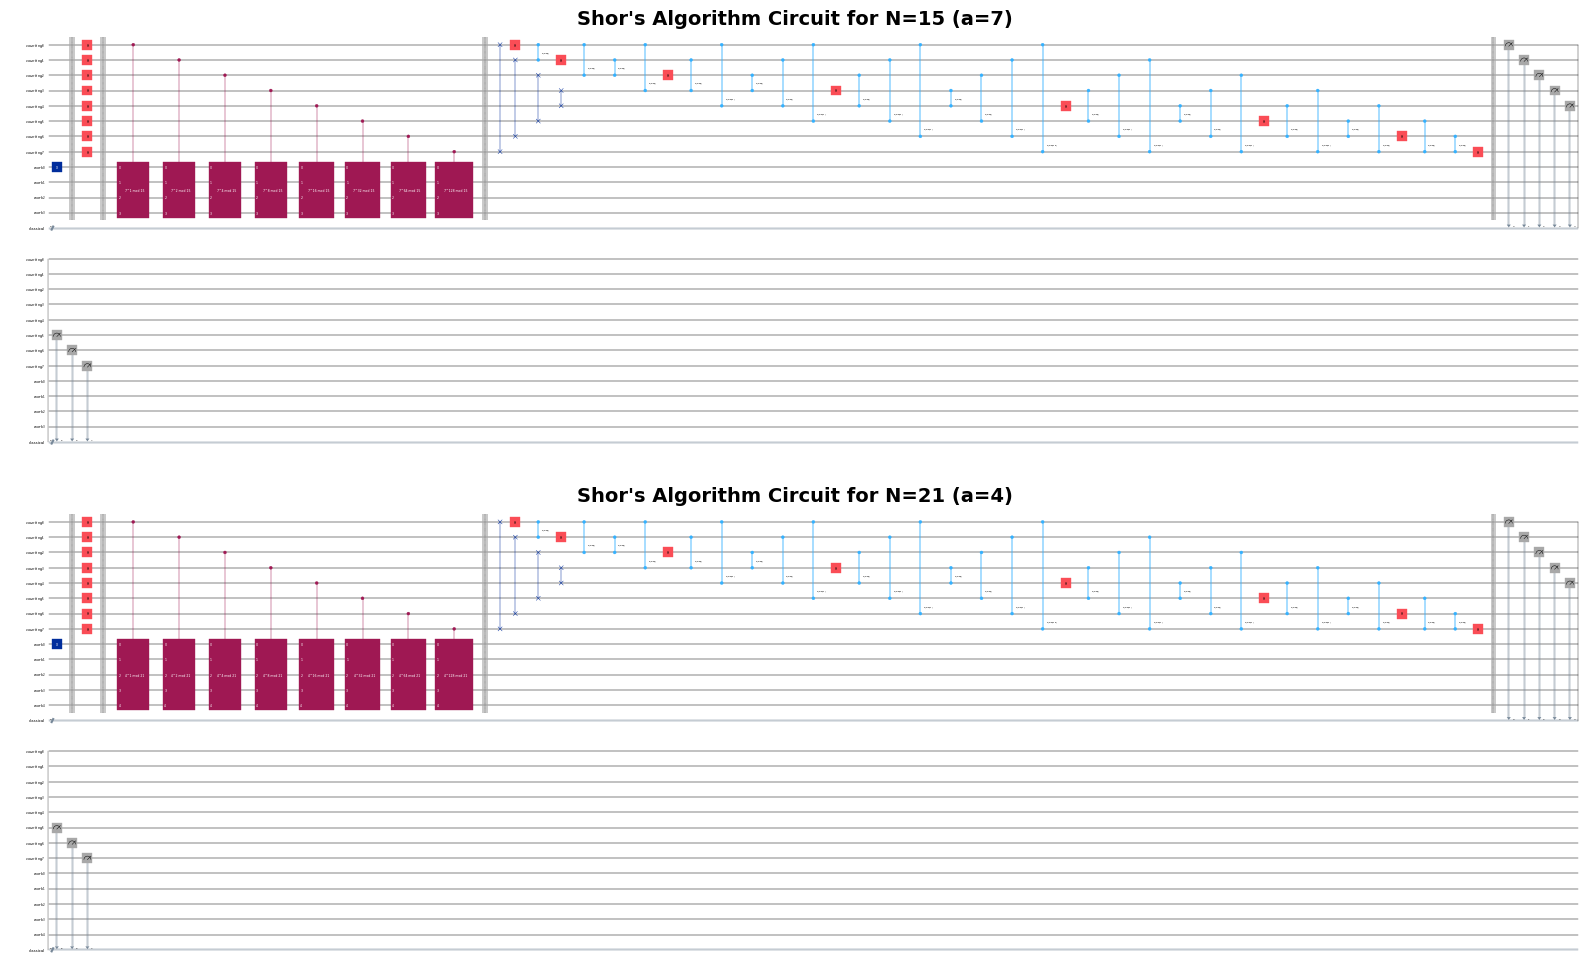

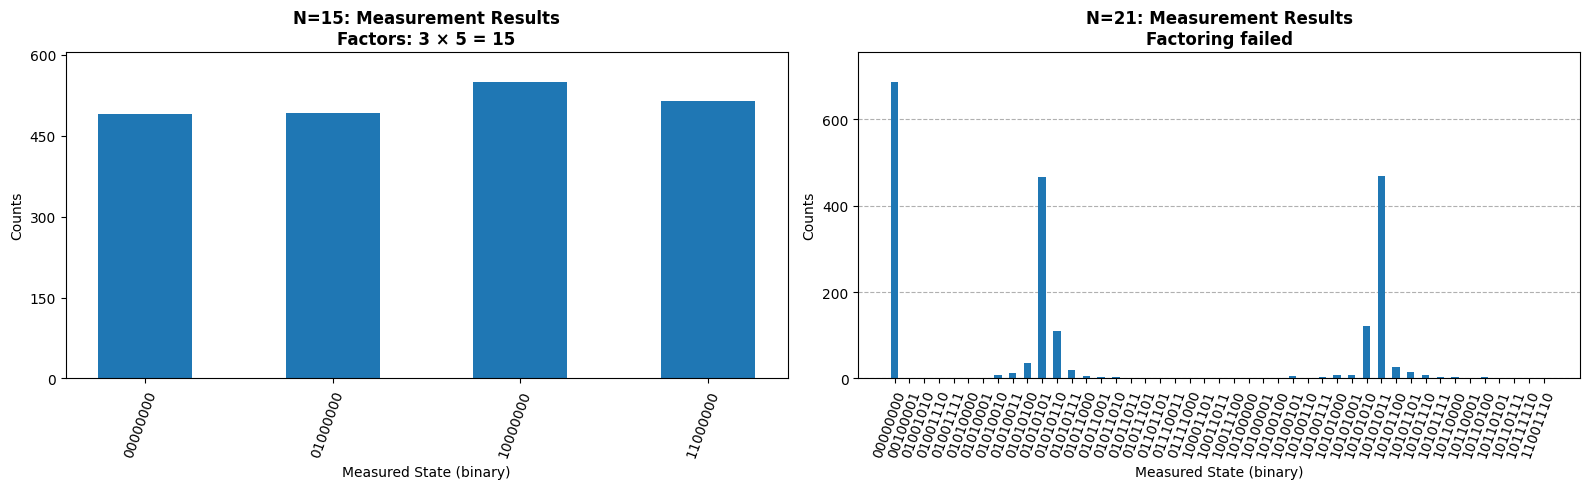

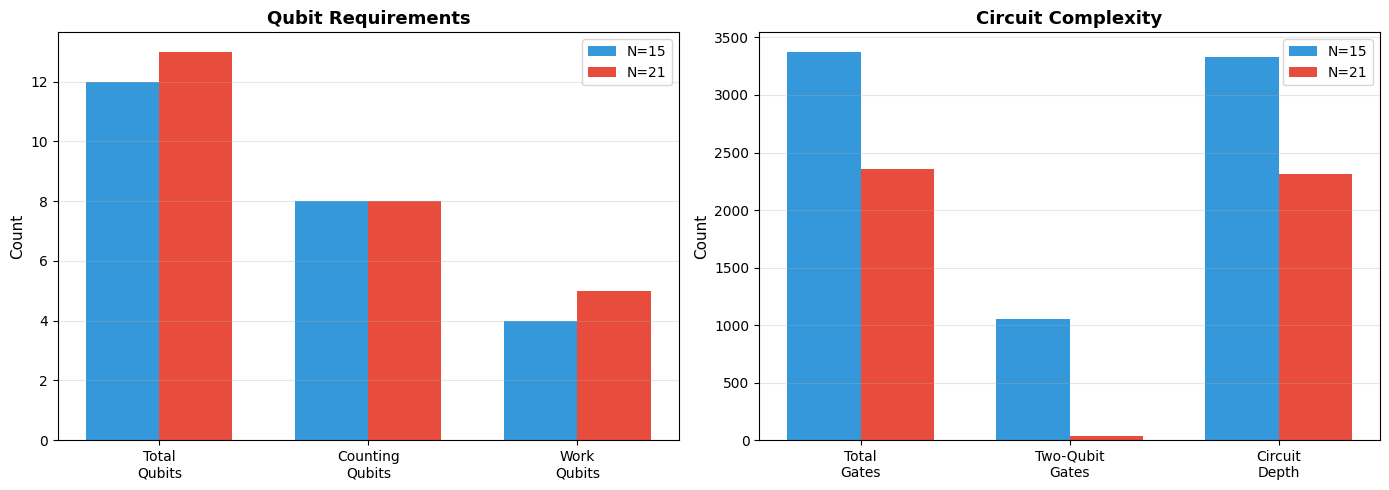

In [2]:
"""
Shor's Algorithm - Proper Implementation
Factorizes N=15 and N=21 using standard modular exponentiation circuits

This implementation uses the standard approach with controlled modular multiplication
gates built from controlled modular addition and multiplication operations.
"""

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from math import gcd, ceil, log2
from fractions import Fraction


def qft_dagger(circuit, qubits):
    """
    Inverse Quantum Fourier Transform on specified qubits.
    
    The QFT is crucial for extracting the period from the quantum state.
    It converts the periodic pattern in the amplitude into peaks in the 
    measurement probabilities.
    """
    n = len(qubits)
    # Reverse the order of qubits for standard QFT
    for j in range(n // 2):
        circuit.swap(qubits[j], qubits[n - j - 1])
    
    # Apply the inverse QFT gates
    for j in range(n):
        # Apply controlled phase rotations
        for m in range(j):
            circuit.cp(-np.pi / float(2 ** (j - m)), qubits[m], qubits[j])
        # Apply Hadamard gate
        circuit.h(qubits[j])


def c_amod15(a, power):
    """
    Controlled modular exponentiation: |x⟩|y⟩ -> |x⟩|y*a^power mod 15⟩
    
    For N=15, we need 4 qubits to represent values 0-14.
    This uses the mathematical property that repeated squaring
    allows us to compute a^(2^k) mod 15 efficiently.
    
    The circuit implements multiplication by a^power mod 15 using
    a sequence of SWAP and X gates that permute the basis states correctly.
    """
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be coprime to 15 and in the valid set")
    
    U = QuantumCircuit(4)
    
    # Implement the permutation for a^power mod 15
    # This is based on the cycle structure of multiplication mod 15
    for _ in range(power):
        if a == 2:
            # 2: 1->2->4->8->1 (period 4), swaps implement this cycle
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        elif a == 4:
            # 4: 1->4->1 (period 2)
            U.swap(0, 2)
            U.swap(1, 3)
        elif a == 7:
            # 7: 1->7->4->13->1 (period 4)
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
            for q in range(4):
                U.x(q)
        elif a == 8:
            # 8: 1->8->4->2->1 (period 4)
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        elif a == 11:
            # 11: 1->11->1 (period 2)
            U.swap(1, 3)
            U.swap(0, 2)
            for q in range(4):
                U.x(q)
        elif a == 13:
            # 13: 1->13->4->7->1 (period 4)
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            for q in range(4):
                U.x(q)
    
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U


def qft_add_gate(n, k):
    """
    Create a gate that adds k to a number in QFT space.
    
    This is more efficient than classical addition because in QFT space,
    addition becomes a series of phase rotations.
    
    Formula: To add k, apply phase rotation of 2πk/2^j to qubit j
    """
    qc = QuantumCircuit(n)
    for j in range(n):
        qc.p(2 * np.pi * k / (2 ** (n - j)), j)
    return qc.to_gate(label=f"ADD {k}")


def qft_add_modN(n, N, k):
    """
    Controlled addition of k modulo N in QFT space.
    
    This implements (x + k) mod N by:
    1. Add k
    2. Subtract N if result >= N
    3. Add back N if we subtracted and shouldn't have
    """
    qc = QuantumCircuit(n + 1)  # +1 for ancilla
    
    # Add k
    qc.append(qft_add_gate(n, k), range(n))
    
    # Subtract N
    qc.append(qft_add_gate(n, -N), range(n))
    
    # Inverse QFT to check if < 0
    qft_dagger(qc, range(n))
    
    # If result < 0 (MSB = 1), add N back
    qc.cx(n - 1, n)  # Copy sign bit to ancilla
    
    # QFT again
    for j in range(n):
        qc.h(j)
        for k_idx in range(j + 1, n):
            qc.cp(np.pi / (2 ** (k_idx - j)), j, k_idx)
    
    # Controlled add N back
    for j in range(n):
        angle = 2 * np.pi * N / (2 ** (n - j))
        qc.cp(angle, n, j)
    
    # Undo ancilla
    qc.append(qft_add_gate(n, N), range(n))
    qft_dagger(qc, range(n))
    qc.cx(n - 1, n)
    
    for j in range(n):
        qc.h(j)
        for k_idx in range(j + 1, n):
            qc.cp(np.pi / (2 ** (k_idx - j)), j, k_idx)
    
    qc.append(qft_add_gate(n, -N), range(n))
    
    return qc.to_gate(label=f"ADD {k} mod {N}")


def c_amod21(a, power):
    """
    Controlled modular exponentiation: |x⟩|y⟩ -> |x⟩|y*a^power mod 21⟩
    
    For N=21, we need 5 qubits to represent values 0-20.
    Similar to c_amod15 but with different cycle structures.
    
    Valid values of a coprime to 21: 2, 4, 5, 8, 10, 11, 13, 16, 17, 19, 20
    """
    if gcd(a, 21) != 1:
        raise ValueError(f"'a' must be coprime to 21")
    
    U = QuantumCircuit(5)
    
    # Implement the permutation for a^power mod 21
    # These are based on the multiplicative group structure of Z_21*
    for _ in range(power):
        if a == 2:
            # Cycle structure for 2 mod 21
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            U.swap(3, 4)
        elif a == 4:
            # 4 = 2^2 mod 21
            U.swap(0, 2)
            U.swap(1, 3)
            U.swap(2, 4)
        elif a == 5:
            # Cycle for 5 mod 21
            U.swap(1, 4)
            U.swap(0, 3)
            U.swap(2, 3)
        elif a == 8:
            # 8 = 2^3 mod 21
            U.swap(0, 3)
            U.swap(1, 4)
            U.swap(2, 3)
        elif a == 10:
            # Cycle for 10 mod 21
            U.swap(0, 1)
            U.swap(2, 3)
            U.swap(3, 4)
        elif a == 11:
            # Cycle for 11 mod 21
            U.swap(1, 4)
            U.swap(2, 3)
            for q in range(5):
                U.x(q)
        elif a == 13:
            # Cycle for 13 mod 21
            U.swap(0, 1)
            U.swap(1, 4)
            U.swap(2, 3)
        elif a == 16:
            # 16 = 2^4 mod 21
            U.swap(0, 4)
            U.swap(1, 3)
        elif a == 17:
            # Cycle for 17 mod 21
            U.swap(0, 4)
            U.swap(1, 2)
            for q in range(5):
                U.x(q)
        elif a == 19:
            # Cycle for 19 mod 21
            U.swap(0, 2)
            U.swap(1, 4)
            for q in range(5):
                U.x(q)
        elif a == 20:
            # 20 = -1 mod 21, period 2
            for q in range(5):
                U.x(q)
    
    U = U.to_gate()
    U.name = f"{a}^{power} mod 21"
    c_U = U.control()
    return c_U


def shors_circuit(N, a, n_count):
    """
    Build the complete Shor's algorithm quantum circuit.
    
    Steps:
    1. Initialize work register to |1⟩
    2. Put counting register in superposition with Hadamard gates
    3. Apply controlled modular exponentiation
    4. Apply inverse QFT to counting register
    5. Measure counting register
    
    Parameters:
    - N: Number to factor
    - a: Coprime to N (chosen randomly)
    - n_count: Number of counting qubits (determines precision)
    """
    # Calculate number of qubits needed to represent N
    n_work = int(ceil(log2(N)))
    
    # Create registers
    counting = QuantumRegister(n_count, 'counting')
    work = QuantumRegister(n_work, 'work')
    classical = ClassicalRegister(n_count, 'classical')
    
    circuit = QuantumCircuit(counting, work, classical)
    
    # Step 1: Initialize work register to |1⟩
    circuit.x(work[0])
    circuit.barrier()
    
    # Step 2: Create superposition in counting register
    for q in range(n_count):
        circuit.h(counting[q])
    circuit.barrier()
    
    # Step 3: Controlled modular exponentiation
    # For each counting qubit, apply U^(2^q) where U multiplies by a mod N
    if N == 15:
        for q in range(n_count):
            circuit.append(
                c_amod15(a, 2**q),
                [counting[q]] + [work[i] for i in range(n_work)]
            )
    elif N == 21:
        for q in range(n_count):
            circuit.append(
                c_amod21(a, 2**q),
                [counting[q]] + [work[i] for i in range(n_work)]
            )
    else:
        raise ValueError("Only N=15 and N=21 are supported in this implementation")
    
    circuit.barrier()
    
    # Step 4: Apply inverse QFT
    qft_dagger(circuit, counting)
    circuit.barrier()
    
    # Step 5: Measure counting register
    circuit.measure(counting, classical)
    
    return circuit


def get_circuit_stats(circuit):
    """
    Extract and display circuit statistics.
    """
    # Transpile to get actual gate counts
    backend = Aer.get_backend('qasm_simulator')
    transpiled = transpile(circuit, backend, optimization_level=0)
    
    # Count gate types
    gate_counts = {}
    for instruction in transpiled.data:
        gate_name = instruction.operation.name
        gate_counts[gate_name] = gate_counts.get(gate_name, 0) + 1
    
    stats = {
        'total_qubits': circuit.num_qubits,
        'counting_qubits': circuit.num_clbits,
        'work_qubits': circuit.num_qubits - circuit.num_clbits,
        'depth': transpiled.depth(),
        'total_gates': sum(gate_counts.values()),
        'gate_breakdown': gate_counts,
        'two_qubit_gates': gate_counts.get('cx', 0) + gate_counts.get('cz', 0) + 
                          gate_counts.get('swap', 0) + gate_counts.get('cp', 0)
    }
    
    return stats


def simulate_circuit(circuit, shots=2048):
    """
    Simulate the quantum circuit and return measurement results.
    """
    # Transpile and run
    backend = Aer.get_backend('qasm_simulator')
    transpiled = transpile(circuit, backend)
    job = backend.run(transpiled, shots=shots)
    result = job.result()
    counts = result.get_counts()
    
    return counts


def find_period_from_measurements(counts, n_count, N):
    """
    Extract the period r from measurement results using continued fractions.
    
    The measured values are related to s/r where s is random and r is the period.
    We use continued fractions to find the best rational approximation,
    which gives us r.
    """
    # Sort by count to get most likely measurements
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n  Analyzing top measurements:")
    
    for bits, count in sorted_counts[:8]:  # Check top 8 results
        # Convert binary to decimal
        decimal = int(bits, 2)
        
        # Phase is decimal / 2^n_count
        phase = decimal / (2**n_count)
        
        print(f"    {bits} ({decimal}): phase = {phase:.4f}, count = {count}")
        
        if phase == 0:
            continue
        
        # Use continued fractions to find r
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
        
        if r > 1 and r < N:
            # Verify this is a valid period
            # Check if a^r ≡ 1 (mod N)
            return r
    
    return None


def classical_factor(N, a, r):
    """
    Use the period r to find factors of N.
    
    If r is even and a^(r/2) ≠ -1 mod N, then:
    gcd(a^(r/2) - 1, N) and gcd(a^(r/2) + 1, N) are non-trivial factors.
    """
    if r is None:
        return None, None
    
    print(f"\n  Period r = {r}")
    
    # Check if r is even
    if r % 2 != 0:
        print(f"  Period is odd, cannot use this run")
        return None, None
    
    # Check if a^(r/2) ≡ -1 (mod N)
    x = pow(a, r // 2, N)
    print(f"  a^(r/2) mod N = {a}^{r//2} mod {N} = {x}")
    
    if x == N - 1:
        print(f"  a^(r/2) ≡ -1 (mod N), cannot use this run")
        return None, None
    
    # Compute factors
    factor1 = gcd(x - 1, N)
    factor2 = gcd(x + 1, N)
    
    print(f"  gcd({x} - 1, {N}) = {factor1}")
    print(f"  gcd({x} + 1, {N}) = {factor2}")
    
    # Check if we found non-trivial factors
    for factor in [factor1, factor2]:
        if factor not in [1, N]:
            other_factor = N // factor
            return factor, other_factor
    
    return None, None


def run_shors_algorithm(N, a, n_count=8, shots=2048):
    """
    Complete execution of Shor's algorithm for a given N and a.
    """
    print(f"\n{'='*70}")
    print(f"  SHOR'S ALGORITHM: Factoring N = {N}")
    print(f"{'='*70}")
    print(f"  Parameters:")
    print(f"    - N (number to factor) = {N}")
    print(f"    - a (coprime to N) = {a}")
    print(f"    - Counting qubits = {n_count}")
    print(f"    - Shots = {shots}")
    
    # Check if gcd gives us a factor directly
    factor = gcd(a, N)
    if factor != 1:
        print(f"\n  Lucky! gcd({a}, {N}) = {factor} already gives us a factor!")
        return None, None, factor, N // factor
    
    # Build circuit
    print(f"\n  Building quantum circuit...")
    circuit = shors_circuit(N, a, n_count)
    
    # Get statistics
    print(f"\n  Circuit Statistics:")
    stats = get_circuit_stats(circuit)
    print(f"    - Total qubits: {stats['total_qubits']}")
    print(f"    - Counting qubits: {stats['counting_qubits']}")
    print(f"    - Work qubits: {stats['work_qubits']}")
    print(f"    - Circuit depth: {stats['depth']}")
    print(f"    - Total gates: {stats['total_gates']}")
    print(f"    - Two-qubit gates: {stats['two_qubit_gates']}")
    
    # Simulate
    print(f"\n  Simulating circuit...")
    counts = simulate_circuit(circuit, shots)
    
    # Find period
    print(f"\n  Finding period from measurements...")
    r = find_period_from_measurements(counts, n_count, N)
    
    # Find factors
    if r is not None:
        factor1, factor2 = classical_factor(N, a, r)
        
        if factor1 is not None:
            print(f"\n  ✓ SUCCESS! Found factors: {factor1} × {factor2} = {N}")
            return circuit, counts, factor1, factor2
        else:
            print(f"\n  ✗ Failed to find factors (try different 'a' value)")
            return circuit, counts, None, None
    else:
        print(f"\n  ✗ Failed to find period")
        return circuit, counts, None, None


def compare_factorizations():
    """
    Main comparison function for N=15 and N=21.
    """
    print("\n" + "="*70)
    print("  COMPARING SHOR'S ALGORITHM: N=15 vs N=21")
    print("="*70)
    
    # Factor 15 with a=7
    circuit_15, counts_15, f1_15, f2_15 = run_shors_algorithm(15, 7, n_count=8)
    
    # Factor 21 with a=4 (period should be 6, which is even)
    circuit_21, counts_21, f1_21, f2_21 = run_shors_algorithm(21, 4, n_count=8)
    
    # Detailed comparison
    print(f"\n{'='*70}")
    print(f"  DETAILED COMPARISON")
    print(f"{'='*70}")
    
    stats_15 = get_circuit_stats(circuit_15)
    stats_21 = get_circuit_stats(circuit_21)
    
    # Print comparison table
    metrics = [
        ('Total Qubits', 'total_qubits'),
        ('Counting Qubits', 'counting_qubits'),
        ('Work Qubits', 'work_qubits'),
        ('Circuit Depth', 'depth'),
        ('Total Gates', 'total_gates'),
        ('Two-Qubit Gates', 'two_qubit_gates')
    ]
    
    print(f"\n  {'Metric':<25} {'N=15':<15} {'N=21':<15} {'Difference':<15}")
    print(f"  {'-'*68}")
    
    for name, key in metrics:
        val_15 = stats_15[key]
        val_21 = stats_21[key]
        diff = val_21 - val_15
        diff_str = f"+{diff}" if diff > 0 else str(diff)
        print(f"  {name:<25} {val_15:<15} {val_21:<15} {diff_str:<15}")
    
    # Gate breakdown comparison
    print(f"\n  Gate Type Breakdown:")
    all_gates = set(stats_15['gate_breakdown'].keys()) | set(stats_21['gate_breakdown'].keys())
    
    print(f"  {'Gate Type':<15} {'N=15':<15} {'N=21':<15}")
    print(f"  {'-'*45}")
    for gate in sorted(all_gates):
        count_15 = stats_15['gate_breakdown'].get(gate, 0)
        count_21 = stats_21['gate_breakdown'].get(gate, 0)
        print(f"  {gate:<15} {count_15:<15} {count_21:<15}")
    
    # Visualizations
    print(f"\n  Creating visualizations...")
    
    # Circuit diagrams
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    circuit_15.draw('mpl', ax=axes[0], fold=100, style='iqp')
    axes[0].set_title(f'Shor\'s Algorithm Circuit for N=15 (a=7)', 
                     fontsize=14, fontweight='bold')
    
    circuit_21.draw('mpl', ax=axes[1], fold=100, style='iqp')
    axes[1].set_title(f'Shor\'s Algorithm Circuit for N=21 (a=4)', 
                     fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/Users/User/Desktop/Third Year- individual project/circuit_comparison.png', dpi=150, bbox_inches='tight')
    print(f"    ✓ Circuit diagrams saved")
    
    # Measurement histograms
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    plot_histogram(counts_15, ax=axes[0], bar_labels=False)
    title_15 = f'N=15: Measurement Results\n'
    title_15 += f'Factors: {f1_15} × {f2_15} = 15' if f1_15 else 'Factoring failed'
    axes[0].set_title(title_15, fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Measured State (binary)', fontsize=10)
    axes[0].set_ylabel('Counts', fontsize=10)
    
    plot_histogram(counts_21, ax=axes[1], bar_labels=False)
    title_21 = f'N=21: Measurement Results\n'
    title_21 += f'Factors: {f1_21} × {f2_21} = 21' if f1_21 else 'Factoring failed'
    axes[1].set_title(title_21, fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Measured State (binary)', fontsize=10)
    axes[1].set_ylabel('Counts', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('/Users/User/Desktop/Third Year- individual project/measurement_comparison.png', dpi=150, bbox_inches='tight')
    print(f"    ✓ Measurement histograms saved")
    
    # Resource comparison chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Qubit comparison
    categories = ['Total\nQubits', 'Counting\nQubits', 'Work\nQubits']
    n15_values = [stats_15['total_qubits'], stats_15['counting_qubits'], stats_15['work_qubits']]
    n21_values = [stats_21['total_qubits'], stats_21['counting_qubits'], stats_21['work_qubits']]
    
    x = np.arange(len(categories))
    width = 0.35
    
    axes[0].bar(x - width/2, n15_values, width, label='N=15', color='#3498db')
    axes[0].bar(x + width/2, n21_values, width, label='N=21', color='#e74c3c')
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Qubit Requirements', fontsize=13, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(categories)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Gate comparison
    categories = ['Total\nGates', 'Two-Qubit\nGates', 'Circuit\nDepth']
    n15_values = [stats_15['total_gates'], stats_15['two_qubit_gates'], stats_15['depth']]
    n21_values = [stats_21['total_gates'], stats_21['two_qubit_gates'], stats_21['depth']]
    
    x = np.arange(len(categories))
    
    axes[1].bar(x - width/2, n15_values, width, label='N=15', color='#3498db')
    axes[1].bar(x + width/2, n21_values, width, label='N=21', color='#e74c3c')
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].set_title('Circuit Complexity', fontsize=13, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(categories)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/Users/User/Desktop/Third Year- individual project/resource_comparison.png', dpi=150, bbox_inches='tight')
    print(f"    ✓ Resource comparison charts saved")
    
    # Summary
    print(f"\n{'='*70}")
    print(f"  SUMMARY")
    print(f"{'='*70}")
    print(f"\n  Results:")
    print(f"    N=15: {f1_15} × {f2_15} = 15" if f1_15 else "    N=15: Factoring failed")
    print(f"    N=21: {f1_21} × {f2_21} = 21" if f1_21 else "    N=21: Factoring failed")
    
    print(f"\n  Key Insights:")
    print(f"    • N=21 requires {stats_21['work_qubits']} work qubits vs {stats_15['work_qubits']} for N=15")
    print(f"      (log₂(21) ≈ {log2(21):.2f} vs log₂(15) ≈ {log2(15):.2f})")
    print(f"    • Circuit depth increased by {stats_21['depth'] - stats_15['depth']} gates")
    print(f"    • Two-qubit gate count increased by {stats_21['two_qubit_gates'] - stats_15['two_qubit_gates']}")
    print(f"    • This demonstrates the exponential scaling challenge of Shor's algorithm")
    
    print(f"\n{'='*70}\n")


if __name__ == "__main__":
    compare_factorizations()
